# AG-HYPOPT · Trial 12

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eleven trials recorded, objective order: trial_09 0.1657 (BEST), trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_08 0.1948, trial_04 0.1987, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor) and the objective is set by the gamma term, dominated by low transmission; that gamma term is highly unstable (trial_09 best and trial_10 worst were near neighbours). The good region uses high sigma_ref (~20-25), high lr_gamma (~0.85-0.9), low-to-mid lr_mu and moderate anneal (~0.4-0.6). TPE (11/5) is exploiting. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_12'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (11/5 trials)
ID |     ei | params
 1 | 1.1804 | {"gamma_anneal": 0.4845279846559198, "lr_gamma": 0.3434331283344861, "lr_mu": 5.0, "sigma_ref": 5.0}
 2 | 1.6228 | {"gamma_anneal": 0.45707092500141766, "lr_gamma": 0.6331729293750354, "lr_mu": 11.448873969024756, "sigma_ref": 25.0}
 3 | 3.1705 | {"gamma_anneal": 0.4776349148374577, "lr_gamma": 0.9071263319779149, "lr_mu": 16.528680909298796, "sigma_ref": 23.42651851932735}
 4 | 1.8366 | {"gamma_anneal": 0.7025220936968503, "lr_gamma": 0.8175411885257985, "lr_mu": 5.0, "sigma_ref": 20.994464211266756}
 5 | 0.6087 | {"gamma_anneal": 0.2848554385592914, "lr_gamma": 0.8109000717101371, "lr_mu": 28.64001703246515, "sigma_ref": 17.00220571059202}
 6 | 2.9716 | {"gamma_anneal": 0.36917324922198846, "lr_gamma": 0.8243062410344839, "lr_mu": 10.91951528402733, "sigma_ref": 5.0}
 7 | 1.5620 | {"gamma_anneal": 0.6458168923011044, "lr_gamma": 0.9770544724369364, "lr_mu": 28.67420511817967, "sigma_ref": 25.0}
 8 | 3.0366 | {"gamma_ann

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (11/5) ranks by expected improvement. The highest-EI candidate is candidate 3 (EI 3.17): gamma_anneal 0.478, lr_gamma 0.907, lr_mu 16.53, sigma_ref 23.43 -- high sigma_ref and high lr_gamma with a moderate anneal, consistent with the broad good region but with a higher lr_mu than the best trials. The runner-up, candidate 8 (EI 3.04), is closer to the trial_09 recipe (lr_mu 8.61, lr_gamma at the 1.0 boundary, sigma_ref 20.80), and candidate 6 (EI 2.97) drops sigma_ref to 5.0. Since the top-EI pick sits in the region the evidence favours (high sigma_ref, high lr_gamma, moderate anneal), I follow it. I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3               # highest-EI TPE pick


chosen: {'gamma_anneal': 0.4776349148374577, 'lr_gamma': 0.9071263319779149, 'lr_mu': 16.528680909298796, 'sigma_ref': 23.42651851932735}
Running  1nW Trans05 ... 

μ 9.39 -> 4.71 | γ 8.5 -> 1.72 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 9.02 | NLL 3.05


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 50.35 | γ 14.1 -> 13.48 | NLL 2.94


Running 3nW Trans100 ... 

μ 175.71 -> 85.58 | γ 14.1 -> 13.84 | NLL 2.86



Total: 2.4 min


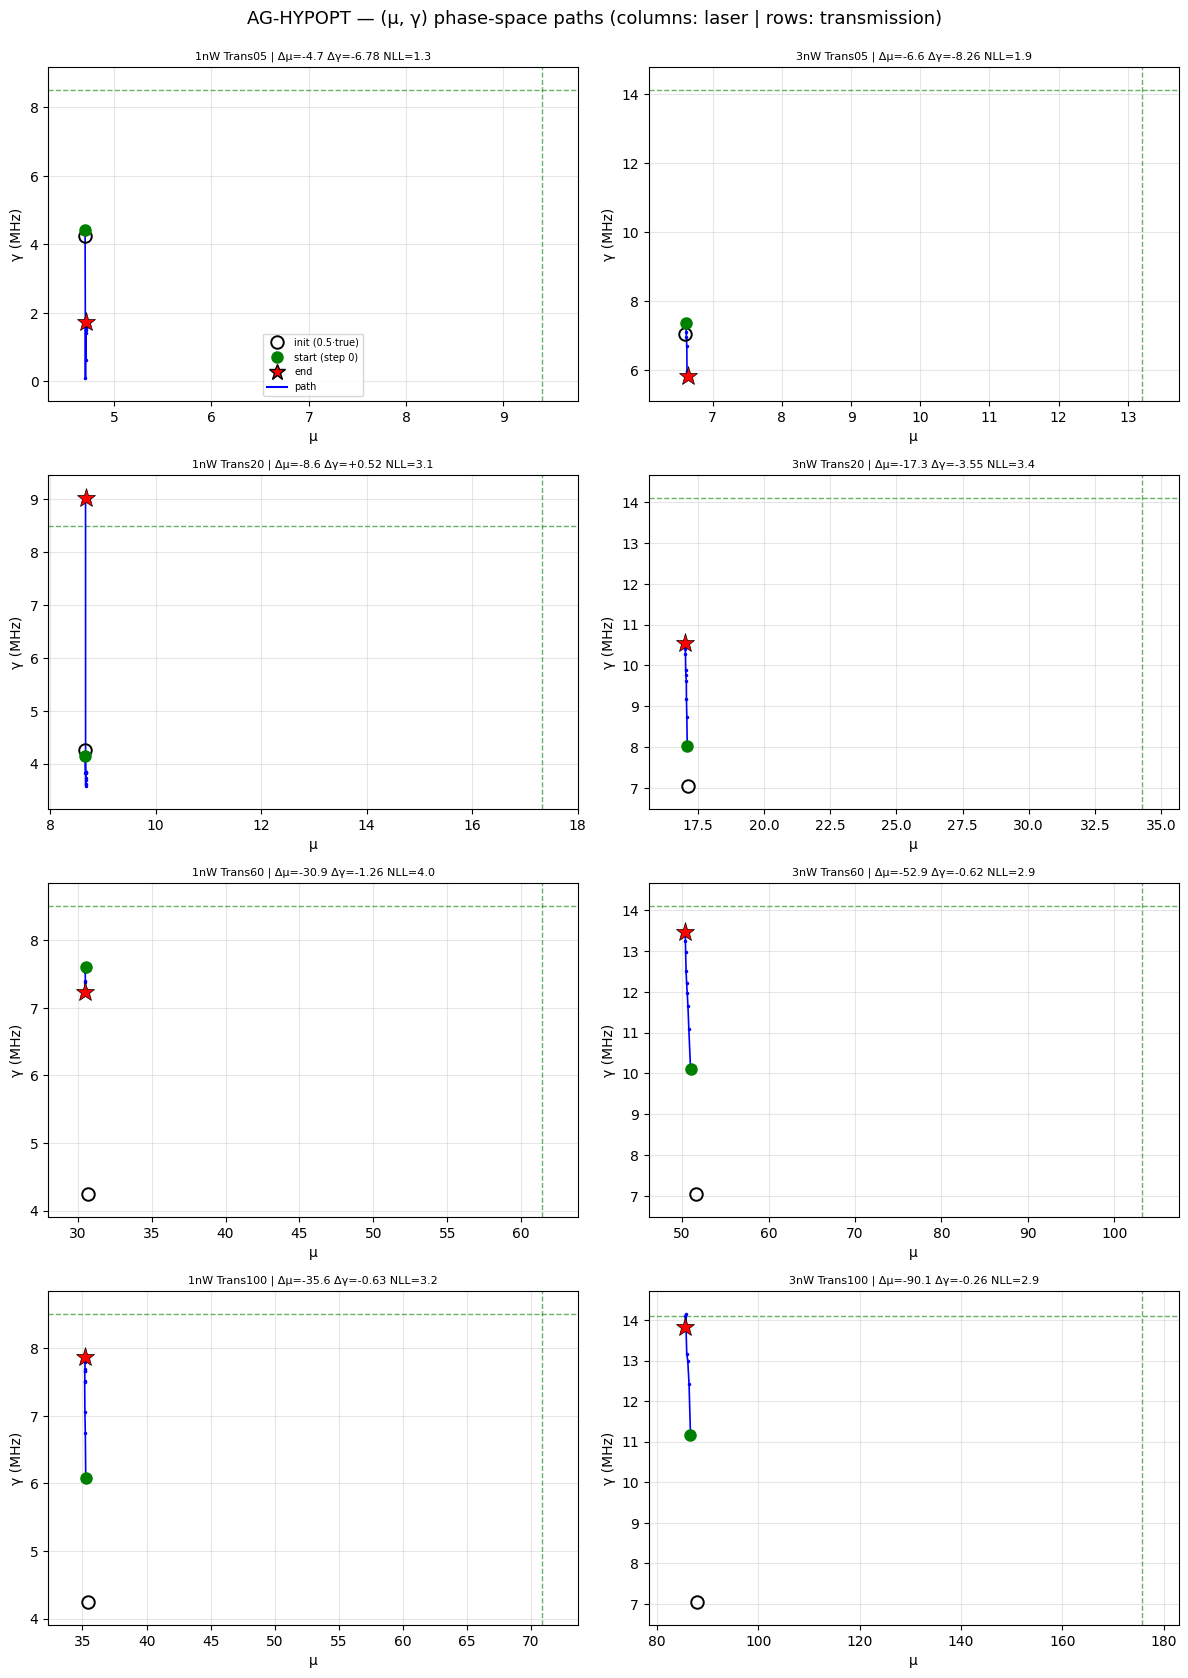

trial finished in 2.4 min
objective = 0.1941 ± 0.0428
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.71   -49.8 |     8.50    1.72   -79.7
1nW Trans20    17.32    8.67   -49.9 |     8.50    9.02    +6.1
1nW Trans60    61.37   30.47   -50.3 |     8.50    7.24   -14.9
1nW Trans100   70.82   35.20   -50.3 |     8.50    7.87    -7.5
3nW Trans05    13.20    6.64   -49.7 |    14.10    5.84   -58.6
3nW Trans20    34.28   17.02   -50.3 |    14.10   10.55   -25.2
3nW Trans60   103.20   50.35   -51.2 |    14.10   13.48    -4.4
3nW Trans100  175.71   85.58   -51.3 |    14.10   13.84    -1.8

μ: RMSE 41.196 (rel 50.4%, bias -30.830) | γ: RMSE 4.023 (rel 36.7%, bias -2.606)


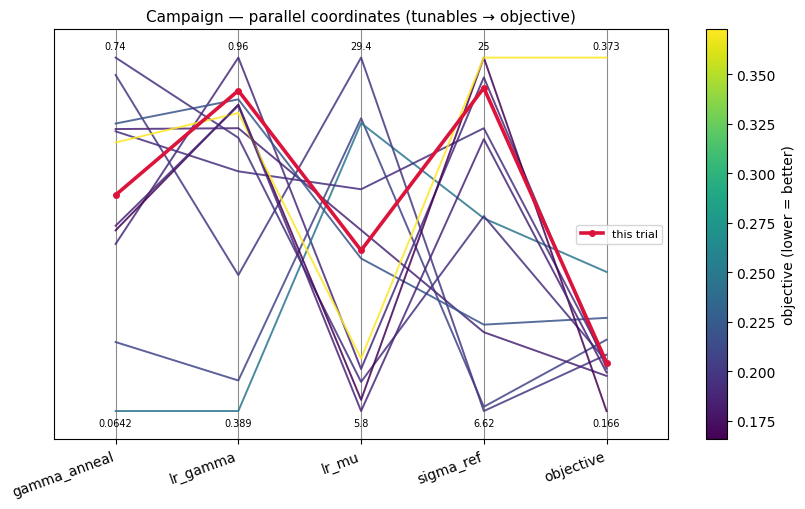

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 12, seventh TPE-driven trial; highest-EI pick: sigma_ref 23.43, lr_mu 16.53, lr_gamma 0.907, gamma_anneal 0.478. Result: objective 0.1941 +/- 0.0428 -- essentially tied with trial_07 (0.1940) and in the middle of the pack; runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.7 to -51.3; mu RMSE 41.20, relative 50.4%). gamma_fit: mid/high transmission is fine (3 nW Trans60/100: -4.4/-1.8%; 1 nW Trans20 +6.1%) but Trans05 collapsed (1 nW -79.7%, 3 nW -58.6%), gamma RMSE 4.02 (relative 36.7%). So a config with a higher lr_mu (16.53) than the best trials landed mid-pack, again with the loss concentrated in the Trans05 gamma.

**Summary:** Trial 12 (sigma_ref 23.43, lr_mu 16.53, lr_gamma 0.907, gamma_anneal 0.478) -> objective 0.1941 +/- 0.0428, mid-pack (tied with trial_07); Trans05 gamma collapsed (-80%/-59%).
**Key insight:** Raising lr_mu to 16.5 did not help -- the result matches the trial_07 mid-pack level, and the loss again comes from the unstable Trans05 gamma rather than the mu term.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 12 (sigma_ref 23.43, lr_mu 16.53, lr_gamma 0.907, gamma_anneal 0.478): objective 0.1941 +/- 0.0428, mid-pack (tied with trial_07); Trans05 gamma collapsed (-80%/-59%)'
KEY_INSIGHT = 'Raising lr_mu to 16.5 left the objective at the trial_07 mid-pack level; the loss again comes from the unstable Trans05 gamma, not the (invariant) mu term.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_12 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_13.ipynb. Open it and follow its cells from the top.
